# Daily Dip-Buy Swing Screener

**Open it, run all cells, read BUY NOW (and SELL / EXIT if you're holding).**

The idea, plain: **go in on high-conviction dips, cut fast if wrong, ride winners.**
- **Buy a dip** - price oversold (RSI-2 < 10) and/or stretched **>= 1.5 standard deviations
  below the 20/21 band** (`z_band`). We buy the stretch because stocks retrace. **No 200-SMA.**
- **Conviction gate** - only names with a **proven historical win rate** flash BUY NOW.
- **Ride the wave (momentum + mean reversion)** - exit adapts to the name's regime:
  strong names ride to `z >= +1.5`, mixed to `+0.5`, weak just take the bounce back (`z >= 0`).
- **Cut fast if wrong** - a **hard stop** on every trade (default **5%**; you can change it).
  We can always re-enter on the next dip.
- **SELL only when it matters** - the screener shows SELL only when a model position actually
  exits (stop hit = bad buy; or target hit = thesis done). No stateless "sell everything overbought".

> **Research only, not financial advice.**

```bash
pip install -r requirements.txt
```

## 0. Why these rules - the stop/exit study

Backtested over 6 years on 60 popular tickers. Entry = dip (`z<=-1.5` or `RSI-2<10`), buy-only,
exit = adaptive z-target, and we swept the hard stop. Wider stops = fewer whipsaws = higher win rate:

| Hard stop | Win rate | $100 -> (portfolio) |
|---|---|---|
| 3% | ~50% (48-50% stopped out - too tight) | ~$207-252 |
| 4% | ~56% | ~$264-288 |
| **5% (default)** | **~61%** | ~$220-237 |
| 6% | ~64% | ~$260-292 |

So 3% protects the most per trade but gets whipsawed; **4-6% is the sweet spot**. The stop is a
config knob (`STOP_PCT`) and Section 6 re-runs the whole sweep live so you can pick.

## 1. Config - edit me

In [1]:
UNIVERSE_SOURCE = "both"   # "popular" (mega caps + ETFs) | "wsb" | "both"
POPULAR_N = 120            # how many popular names
TOP_N     = 120            # how many WSB names (when source includes wsb)
PERIOD    = "5y"           # daily history (enough to backtest each name's edge)
STOP_PCT  = 0.05           # hard stop per trade (try 0.03 / 0.04 / 0.05 / 0.06)
OUTDIR    = "results"

import wsb_screener.quant_core as qc
qc.STOP_PCT = STOP_PCT     # push the chosen stop into the model
from wsb_screener import quant_screener as qscr
from wsb_screener.quant_report import build_markdown
from wsb_screener.data import get_universe, download_history
from wsb_screener.quant_core import portfolio_backtest, swing_backtest, live_signal, compute_stats
import importlib; importlib.reload(qscr)      # pick up the new STOP_PCT
import pandas as pd
pd.set_option("display.max_rows", 250, "display.width", 260, "display.max_columns", 60)

## 2. Fetch the universe (most popular stocks + ETFs, plus WSB) + daily history

In [2]:
uni   = get_universe(source=UNIVERSE_SOURCE, top_n=TOP_N, popular_n=POPULAR_N)
metas = {d["ticker"]: d for d in uni}
print(f"Universe: {len(metas)} names ({UNIVERSE_SOURCE})")
print(", ".join(list(metas)[:30]), "...")
hist = download_history(list(metas), period=PERIOD, interval="1d")
print(f"\nDownloaded daily data for {len(hist)}/{len(metas)} tickers")

Universe: 200 names (both)
AAPL, MSFT, NVDA, AMZN, GOOGL, GOOG, META, TSLA, AVGO, ORCL, AMD, NFLX, ADBE, CRM, CSCO, QCOM, TXN, INTC, IBM, AMAT, MU, INTU, NOW, UBER, SHOP, PLTR, SMCI, ARM, PANW, SNOW ...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: OS"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}


$OS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


$DAY: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")



2 Failed downloads:


['OS', 'DAY']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")



Downloaded daily data for 198/200 tickers


## 3. Run the model (dip trigger -> conviction gate -> position-aware bucket)

In [3]:
df = qscr.run_screener(hist, metas)
signal_date = df["signal_date"].dropna().mode().iloc[0]
print("Latest daily bar:", signal_date)
df["group"].value_counts()

  ...screened 25/200


  ...screened 50/200


  ...screened 75/200


  ...screened 100/200


  ...screened 125/200


  ...screened 150/200


  ...screened 175/200


  ...screened 200/200
Latest daily bar: 2026-07-09


group
WATCH             96
HOLDING (RIDE)    67
SELL / EXIT       22
CLOSE TO BUY       9
SKIPPED            4
BUY NOW            2
Name: count, dtype: int64

## 4. BUY NOW - high-conviction dips firing today
Oversold / stretched below the band, in names with a proven win rate. Buy at next open;
the `exit_plan` is where you ride to; `stop_%` cuts it if wrong.

In [4]:
buy_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","dist_band_%",
            "vol_surge","bt_winrate_%","exit_plan","stop_%","band_read","note"]
df[df.group=="BUY NOW"][buy_cols]

,group_rank,ticker,name,close,score,rsi2,z_band,dist_band_%,vol_surge,bt_winrate_%,exit_plan,stop_%,band_read,note
0,1,AZZ,AZZ,139.90,56.0,5.7,-1.78,-7.07,1.20,69.4,z>=+0.5,5.0,"-1.8 sigma below band - stretched, buy zone","dip buy (69% hist win): RSI-2 6 (oversold), -1..."
1,2,CMCSA,CMCSA,23.12,37.0,9.9,-0.27,-0.80,0.27,62.5,z>=0 (quick bounce),5.0,at the band,dip buy (62% hist win): RSI-2 10 (oversold) ->...


## 5. CLOSE TO BUY - dips with a moderate edge, or sliding into the zone

In [5]:
near_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","dist_band_%",
             "vol_surge","bt_winrate_%","band_read","note"]
df[df.group=="CLOSE TO BUY"][near_cols]

,group_rank,ticker,name,close,score,rsi2,z_band,dist_band_%,vol_surge,bt_winrate_%,band_read,note
91,1,RTX,RTX,195.10,47.1,25.0,0.87,2.90,0.28,78.8,+0.9 sigma above band - riding above support,RSI-2 25 sliding into oversold -- waiting for ...
92,2,V,V,346.89,42.1,17.5,0.69,2.53,0.37,69.6,+0.7 sigma above band - riding above support,RSI-2 18 sliding into oversold -- waiting for ...
93,3,PG,PG,146.64,41.1,21.2,-1.29,-1.61,0.26,68.8,-1.3 sigma below band - pulling back toward band,RSI-2 21 sliding into oversold; -1.3 sigma bel...
94,4,ABBV,ABBV,249.05,42.1,11.2,0.60,3.54,0.26,68.3,+0.6 sigma above band - riding above support,RSI-2 11 sliding into oversold -- waiting for ...
95,5,DE,DE,597.98,41.7,21.6,-0.11,-0.44,0.27,67.3,at the band,RSI-2 22 sliding into oversold -- waiting for ...
96,6,MA,MA,520.42,47.1,22.9,0.77,2.63,0.24,65.4,+0.8 sigma above band - riding above support,RSI-2 23 sliding into oversold -- waiting for ...
97,7,AMGN,AMGN,363.19,42.1,18.1,0.71,2.05,0.22,65.4,+0.7 sigma above band - riding above support,RSI-2 18 sliding into oversold -- waiting for ...
98,8,ABT,ABT,94.12,42.1,19.1,0.81,2.39,0.20,63.8,+0.8 sigma above band - riding above support,RSI-2 19 sliding into oversold -- waiting for ...
99,9,LEVI,Levi Strauss,24.20,48.9,11.2,0.34,0.71,1.94,53.4,at the band,RSI-2 11 sliding into oversold -- waiting for ...


## 6. SELL / EXIT (only when it matters) + HOLDING (riding)
- **SELL / EXIT** - a model position exited on the latest bar: stop hit (bad buy, cut it) or
  target reached (thesis done). If you're holding that name, act.
- **HOLDING (RIDE)** - entered on a prior dip and still riding toward the target.

In [6]:
sell_cols = ["group_rank","ticker","name","close","entry_price","pos_ret_%","exit_reason","z_band","note"]
hold_cols = ["group_rank","ticker","name","close","entry_price","pos_gain_%","bars_held","z_band","exit_plan","stop_%"]
from IPython.display import display
print("SELL / EXIT");     display(df[df.group=="SELL / EXIT"][sell_cols])
print("HOLDING (RIDE)");  display(df[df.group=="HOLDING (RIDE)"][hold_cols].head(20))

SELL / EXIT


,group_rank,ticker,name,close,entry_price,pos_ret_%,exit_reason,z_band,note
2,1,KORU,Direxion Shares ETF Trust - Direxion Daily Sou...,573.35,625.63,-23.08,stop,-0.98,"SELL: 5% stop hit (-23.1%) - buy was wrong, cu..."
3,2,MU,MU,1018.22,1007.00,-10.36,stop,-0.16,"SELL: 5% stop hit (-10.4%) - buy was wrong, cu..."
4,3,RMBS,Rambus,116.94,115.81,-9.55,stop,-0.75,"SELL: 5% stop hit (-9.6%) - buy was wrong, cut..."
5,4,SMCI,SMCI,28.76,28.42,-8.02,stop,-0.64,"SELL: 5% stop hit (-8.0%) - buy was wrong, cut..."
6,5,WDC,Western Digital,586.83,567.00,-7.23,stop,-0.24,"SELL: 5% stop hit (-7.2%) - buy was wrong, cut..."
7,6,WD,Walker & Dunlop,50.62,52.85,-6.28,stop,-1.03,"SELL: 5% stop hit (-6.3%) - buy was wrong, cut..."
8,7,MP,MP Materials,52.15,53.55,-5.70,stop,-1.26,"SELL: 5% stop hit (-5.7%) - buy was wrong, cut..."
9,8,CSCO,CSCO,118.60,118.16,-5.48,stop,0.56,"SELL: 5% stop hit (-5.5%) - buy was wrong, cut..."
10,9,OR,Osisko Gold Royalties,29.86,30.83,-3.30,stop,-1.17,"SELL: 5% stop hit (-3.3%) - buy was wrong, cut..."
11,10,AGI,Alamos Gold,29.79,30.81,-3.28,stop,-0.98,"SELL: 5% stop hit (-3.3%) - buy was wrong, cut..."


HOLDING (RIDE)


,group_rank,ticker,name,close,entry_price,pos_gain_%,bars_held,z_band,exit_plan,stop_%
24,1,SOXL,Direxion Shares ETF Trust - Direxion Daily Sem...,197.39,159.21,23.98,1.0,-0.60,z>=+0.5,5.0
25,2,SNDK,Sandisk,1942.97,1591.80,22.06,1.0,0.08,z>=+1.5 (ride momentum),5.0
26,3,MSTR,MSTR,95.67,83.23,14.94,8.0,-0.67,z>=0 (quick bounce),5.0
27,4,NBIS,Nebius Group,220.64,192.67,14.52,1.0,-0.67,z>=+1.5 (ride momentum),5.0
28,5,WULF,TeraWulf,23.83,21.06,13.15,1.0,-0.41,z>=+0.5,5.0
29,6,AMC,AMC Entertainment,1.93,1.71,12.67,2.0,-0.42,z>=+1.5 (ride momentum),5.0
30,7,DKNG,DKNG,26.51,23.70,11.86,8.0,0.10,z>=+1.5 (ride momentum),5.0
31,8,ON,ON Semiconductor,100.46,90.20,11.37,7.0,-0.38,z>=+0.5,5.0
32,9,CRWV,CoreWeave,91.18,83.01,9.84,3.0,-0.61,z>=+0.5,5.0
33,10,AMAT,AMAT,595.20,547.10,8.79,1.0,0.01,z>=+1.5 (ride momentum),5.0


## 7. Give it $100 - portfolio backtest + stop sweep
Trades the strategy across the whole universe with **$100**, fixed-fraction sizing (1/8 of equity
per trade, max 8 concurrent positions), for each stop level. Then plots the equity curve at your
chosen `STOP_PCT`.

$100 portfolio - stop-loss sweep:


,stop_%,final_$,return_%,CAGR_%,maxDD_%,trades,win_%
0,3,170.85,70.8,12.0,-31.7,1439,46.3
1,4,239.32,139.3,20.3,-29.4,1231,51.7
2,5,219.95,120.0,18.2,-36.9,1104,55.3
3,6,168.11,68.1,11.6,-27.3,1021,58.1



At your STOP_PCT=5%: $100 -> $219.95 (+120%, CAGR 18.2%/yr, maxDD -36.9%, 1104 trades, 55.3% win)


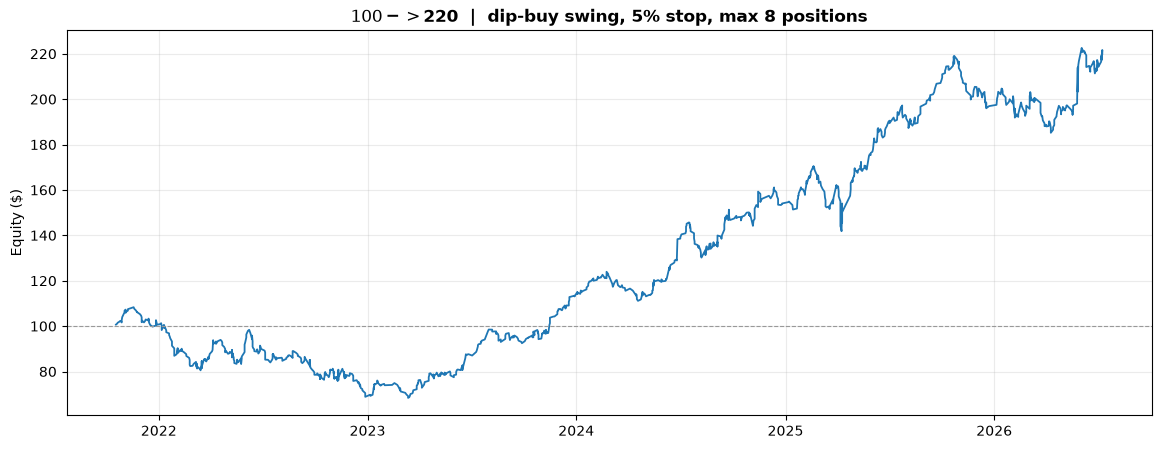

In [7]:
rows = []
for s in (0.03, 0.04, 0.05, 0.06):
    p = portfolio_backtest(hist, start_cash=100.0, max_positions=8, stop_pct=s)
    rows.append({"stop_%": int(s*100), "final_$": p["final_$"], "return_%": p["return_%"],
                 "CAGR_%": p["CAGR_%"], "maxDD_%": p["max_drawdown_%"],
                 "trades": p["trades"], "win_%": p["win_rate_%"]})
sweep = pd.DataFrame(rows)
print("$100 portfolio - stop-loss sweep:")
display(sweep)

port = portfolio_backtest(hist, start_cash=100.0, max_positions=8, stop_pct=STOP_PCT)
print(f"\nAt your STOP_PCT={STOP_PCT:.0%}: $100 -> ${port['final_$']:.2f} "
      f"({port['return_%']:+.0f}%, CAGR {port['CAGR_%']}%/yr, maxDD {port['max_drawdown_%']}%, "
      f"{port['trades']} trades, {port['win_rate_%']}% win)")

%matplotlib inline
import matplotlib.pyplot as plt
eq = port["equity_curve"]
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(eq["date"], eq["equity"], color="#1f77b4", lw=1.3)
ax.axhline(100, color="#999", ls="--", lw=0.8)
ax.set_title(f"$100 -> ${port['final_$']:.0f}  |  dip-buy swing, {STOP_PCT:.0%} stop, max 8 positions", weight="bold")
ax.set_ylabel("Equity ($)"); ax.grid(alpha=0.25); plt.show()

## 8. Save the scan (CSV + Markdown report)

In [8]:
import os
os.makedirs(OUTDIR, exist_ok=True)
df.to_csv(f"{OUTDIR}/wsb_quant_screen.csv", index=False)
with open(f"{OUTDIR}/wsb_quant_report.md", "w") as f:
    f.write(build_markdown(df, len(metas), signal_date, portfolio=port))
print("wrote", f"{OUTDIR}/wsb_quant_screen.csv", "and", f"{OUTDIR}/wsb_quant_report.md")

wrote results/wsb_quant_screen.csv and results/wsb_quant_report.md


## 9. Drill into ANY ticker (not just the universe)
Type any symbol trading on the market - it downloads on the fly, shows price + band + the
dip-buy/exit markers, an RSI-2 panel, and this ticker's own backtest + $100 result.

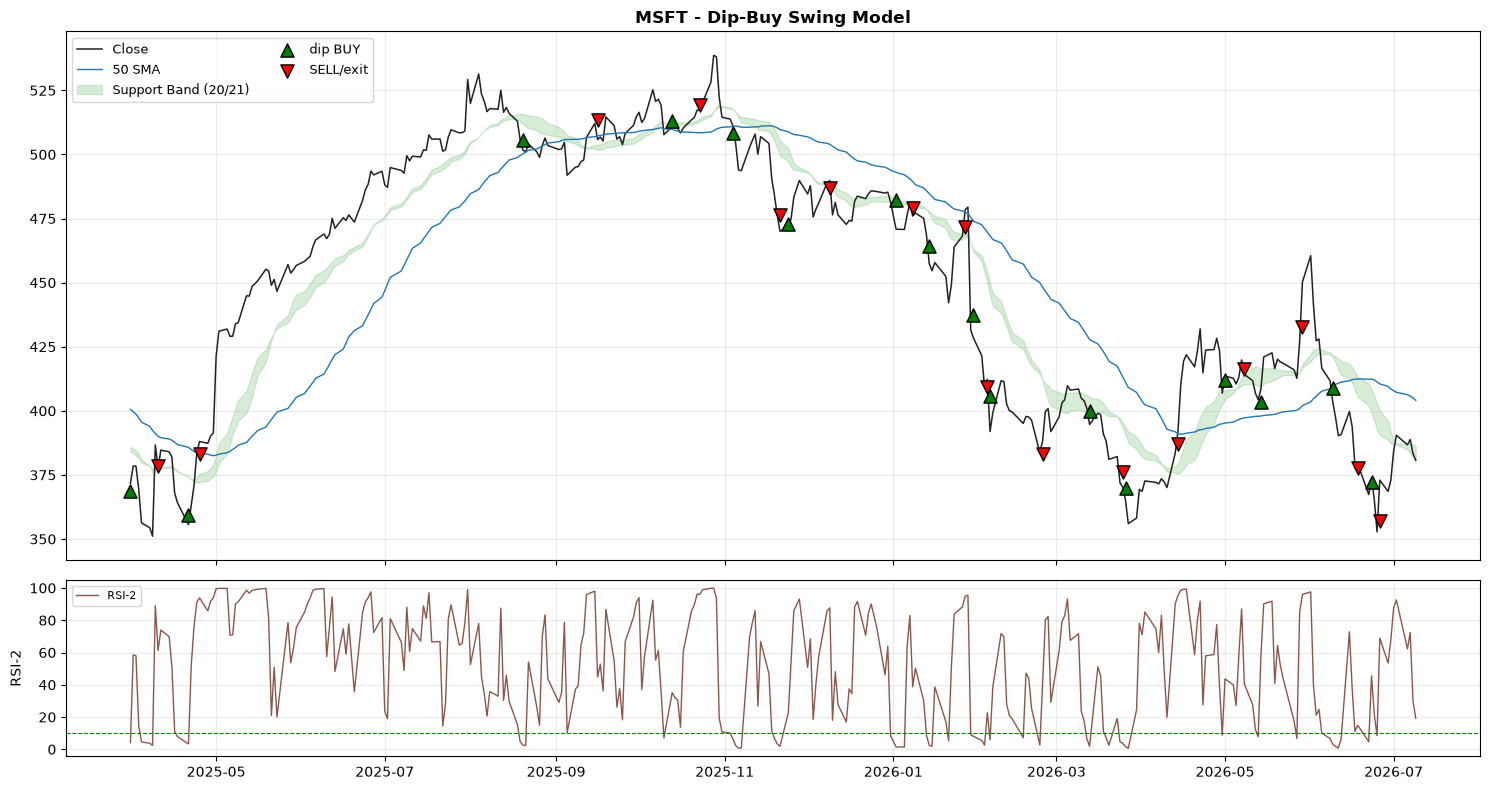

MSFT: score=24.1 | RSI-2=19.2 | z_band=-0.25 (at the band)
if bought now -> exit plan z>=+0.5, 5% stop | dip trigger now: False
this ticker's backtest: {'Total Trades': 53, 'Win Rate %': 69.8, 'Total P&L $': np.float64(495.51), 'Avg Win $': np.float64(37.32), 'Avg Loss $': np.float64(-55.34), 'Profit Factor': np.float64(1.56), 'Expectancy $': np.float64(9.35), 'Avg Bars Held': np.float64(8.8), 'Max Drawdown $': np.float64(-203.77), 'Return/Trade %': np.float64(0.93)}
$100 in ONLY MSFT: -> $153.91 (+54%, 53 trades, 69.8% win)


In [9]:
TICKER = "MSFT"   # <- ANY market ticker (e.g. NVDA, SPY, BTC-USD, TSM, JPM ...)

h = download_history([TICKER], period=PERIOD, interval="1d")
data = h.get(TICKER) if h else None
if data is None or len(data) < 120:
    print(f"No / not enough data for {TICKER!r} - try another symbol.")
else:
    d, t = swing_backtest(data, stop_pct=STOP_PCT)
    sig = live_signal(data)
    view = d.tail(320)
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15,8), sharex=True, gridspec_kw={"height_ratios":[3,1]})
    ax.plot(view.Date, view.Close, color="#222", lw=1.1, label="Close")
    ax.plot(view.Date, view.SMA50, color="#1f77b4", lw=1.0, label="50 SMA")
    ax.fill_between(view.Date, view.band_bot, view.band_top, color="#2ca02c", alpha=0.18, label="Support Band (20/21)")
    tv = t[t.entry_date >= view.Date.iloc[0]] if not t.empty else t
    if not tv.empty:
        ax.scatter(tv.entry_date, tv.entry_price, marker="^", s=90, color="green", edgecolor="k", zorder=5, label="dip BUY")
        ax.scatter(tv.exit_date,  tv.exit_price,  marker="v", s=90, color="red",   edgecolor="k", zorder=5, label="SELL/exit")
    ax.set_title(f"{TICKER} - Dip-Buy Swing Model", weight="bold"); ax.legend(loc="upper left", ncol=2, fontsize=9); ax.grid(alpha=0.25)
    ax2.plot(view.Date, view.RSI2, color="#8c564b", lw=1.0, label="RSI-2"); ax2.axhline(10, color="green", ls="--", lw=0.8)
    ax2.set_ylabel("RSI-2"); ax2.grid(alpha=0.25); ax2.legend(loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()

    print(f"{TICKER}: score={sig['score']} | RSI-2={sig['rsi2']} | z_band={sig['z_band']} ({sig['band_read']})")
    print(f"if bought now -> exit plan {sig['exit_plan']}, {STOP_PCT:.0%} stop | dip trigger now: {sig['trigger']}")
    print("this ticker's backtest:", compute_stats(t))
    single = portfolio_backtest({TICKER: data}, start_cash=100.0, max_positions=1, stop_pct=STOP_PCT)
    print(f"$100 in ONLY {TICKER}: -> ${single['final_$']:.2f} ({single['return_%']:+.0f}%, {single['trades']} trades, {single['win_rate_%']}% win)")